In [1]:
# Import libraries
import os
import json
import pandas as pd
import numpy as np
import xgboost as xgb
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

print("Using XGBoost with TF-IDF vectorization for improved performance")

# Load tabular features
train_df = pd.read_csv('../dataset/train.csv')
print(f"Loaded {len(train_df)} training samples")

# Persist the list of numeric columns used during training for consistent inference
train_numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)
num_cols_path = os.path.join(models_dir, 'train_numeric_cols.json')
with open(num_cols_path, 'w', encoding='utf-8') as f:
    json.dump(train_numeric_cols, f)
print(f"Saved training numeric columns to {num_cols_path} ({len(train_numeric_cols)} cols)")

# Load embeddings
embeddings = np.load('../embeddings/train_embeddings.npz')
embedding_features = embeddings['embeddings']
print(f"Loaded embeddings shape: {embedding_features.shape}")

# Process text data with TF-IDF vectorization
print("Processing text data with TF-IDF vectorization...")
# Clean and prepare text data
train_df['catalog_content'] = train_df['catalog_content'].fillna('')
text_data = train_df['catalog_content'].astype(str)

# Create TF-IDF vectorizer with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit features to top 5000 most important terms
    stop_words='english',
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.95,  # Ignore terms that appear in more than 95% of documents
    sublinear_tf=True,  # Apply sublinear tf scaling
    lowercase=True
)

# Fit and transform the text data
tfidf_features = tfidf_vectorizer.fit_transform(text_data)
tfidf_features_dense = tfidf_features.toarray()
print(f"TF-IDF features shape: {tfidf_features_dense.shape}")

# Save the TF-IDF vectorizer for inference
tfidf_path = os.path.join(models_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, tfidf_path)
print(f"Saved TF-IDF vectorizer to {tfidf_path}")

# Combine all features (ensure only numeric columns are used)
tabular_features = train_df[train_numeric_cols].to_numpy()
print(f"Tabular features shape: {tabular_features.shape}")

# Check for NaN/inf values before combining
print("Checking for NaN/inf values:")
print(f"Tabular features - NaN: {np.isnan(tabular_features).sum()}, Inf: {np.isinf(tabular_features).sum()}")
print(f"Embedding features - NaN: {np.isnan(embedding_features).sum()}, Inf: {np.isinf(embedding_features).sum()}")
print(f"TF-IDF features - NaN: {np.isnan(tfidf_features_dense).sum()}, Inf: {np.isinf(tfidf_features_dense).sum()}")

# Replace any NaN/inf with zeros
tabular_features = np.nan_to_num(tabular_features, nan=0.0, posinf=0.0, neginf=0.0)
embedding_features = np.nan_to_num(embedding_features, nan=0.0, posinf=0.0, neginf=0.0)
tfidf_features_dense = np.nan_to_num(tfidf_features_dense, nan=0.0, posinf=0.0, neginf=0.0)

# Scale TF-IDF features to match the scale of other features
tfidf_scaler = StandardScaler()
tfidf_features_scaled = tfidf_scaler.fit_transform(tfidf_features_dense)

# Save the TF-IDF scaler
tfidf_scaler_path = os.path.join(models_dir, 'tfidf_features_scaler.joblib')
joblib.dump(tfidf_scaler, tfidf_scaler_path)
print(f"Saved TF-IDF scaler to {tfidf_scaler_path}")

# Concatenate all features: tabular + embeddings + TF-IDF
X = np.concatenate([tabular_features, embedding_features, tfidf_features_scaled], axis=1)
y = train_df['price'].values

# Check target values
print(f"Target values - NaN: {np.isnan(y).sum()}, Inf: {np.isinf(y).sum()}")
print(f"Target range: min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")

# Clean target values
y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Final feature matrix shape: {X.shape}")
print(f"Final target shape: {y.shape}")
print(f"Feature breakdown - Tabular: {tabular_features.shape[1]}, Embeddings: {embedding_features.shape[1]}, TF-IDF: {tfidf_features_scaled.shape[1]}")





KeyboardInterrupt: 

Creating lightweight neural network for faster training...
Using device: cpu
Saved feature scaler to ../models\feature_scaler.joblib
Saved feature scaler to ../models\feature_scaler.joblib
Train tensor shape: torch.Size([60000, 6538]), Val tensor shape: torch.Size([15000, 6538])
Total trainable parameters: 3,522,433
Train tensor shape: torch.Size([60000, 6538]), Val tensor shape: torch.Size([15000, 6538])
Total trainable parameters: 3,522,433
Training lightweight neural network...
Training lightweight neural network...
Epoch [1/100], Train Loss: 1341.1463, Val Loss: 1514.3665
Epoch [1/100], Train Loss: 1341.1463, Val Loss: 1514.3665
Epoch [11/100], Train Loss: 91.2869, Val Loss: 200.7611
Epoch [11/100], Train Loss: 91.2869, Val Loss: 200.7611
Epoch [21/100], Train Loss: 57.9786, Val Loss: 192.3662
Epoch [21/100], Train Loss: 57.9786, Val Loss: 192.3662
Epoch [31/100], Train Loss: 51.4038, Val Loss: 143.3226
Epoch [31/100], Train Loss: 51.4038, Val Loss: 143.3226
Epoch [41/100], Train L

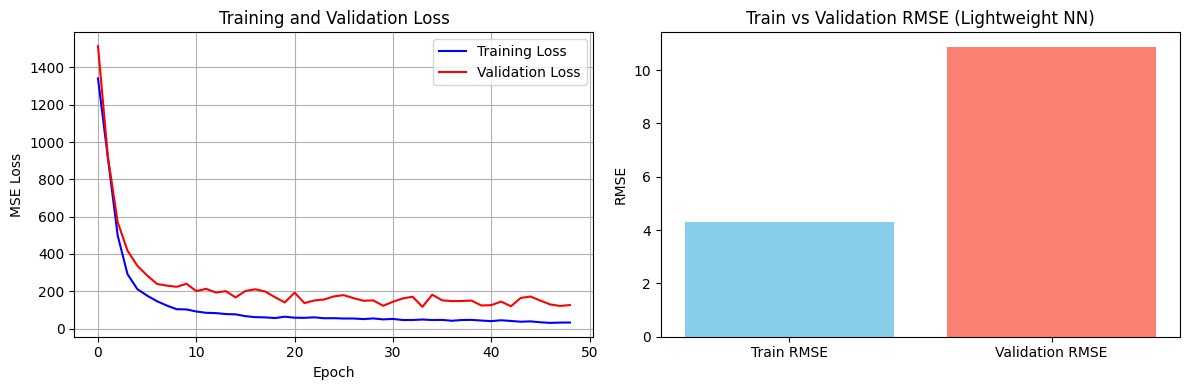

Complete model saved to ../models\lightweight_nn_complete.pth
Lightweight neural network training completed!
Model has 3,522,433 parameters and trained in 49 epochs


In [ ]:
# Import additional libraries for neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

print("Creating lightweight neural network for faster training...")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Scale all features for neural network
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)

# Save the feature scaler
scaler_path = os.path.join(models_dir, 'feature_scaler.joblib')
joblib.dump(feature_scaler, scaler_path)
print(f"Saved feature scaler to {scaler_path}")

# Split data
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1).to(device)

print(f"Train tensor shape: {X_train_tensor.shape}, Val tensor shape: {X_val_tensor.shape}")

# Define lightweight neural network
class LightweightPricePredictor(nn.Module):
    def __init__(self, input_size):
        super(LightweightPricePredictor, self).__init__()
        # Small but effective architecture
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.3)
        
        # Batch normalization for stability
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn4 = nn.BatchNorm1d(64)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.fc5(x)
        return x

# Initialize model
input_size = X_train.shape[1]
model = LightweightPricePredictor(input_size).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Create data loaders for batch training
batch_size = 512
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Training function
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# Validation function
def validate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()
    return total_loss / len(val_loader)

# Training loop
print("Training lightweight neural network...")
num_epochs = 100  # Fast training
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 15

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, val_loader, criterion)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_path = os.path.join(models_dir, 'lightweight_nn_best.pth')
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
    
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    if patience_counter >= early_stopping_patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

# Load best model
model.load_state_dict(torch.load(best_model_path))
print(f"Best model saved to {best_model_path}")

# Final evaluation
model.eval()
with torch.no_grad():
    # Training predictions
    y_train_pred = model(X_train_tensor).cpu().numpy().flatten()
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # Validation predictions
    y_val_pred = model(X_val_tensor).cpu().numpy().flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")

# Calculate SMAPE
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return float(np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100)

val_smape = smape(y_val, y_val_pred)
train_smape = smape(y_train, y_train_pred)
print(f"Training SMAPE: {train_smape:.2f}%")
print(f"Validation SMAPE: {val_smape:.2f}%")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(['Train RMSE', 'Validation RMSE'], [train_rmse, val_rmse], color=['skyblue', 'salmon'])
plt.ylabel('RMSE')
plt.title('Train vs Validation RMSE (Lightweight NN)')

plt.tight_layout()
plt.show()

# Save the complete model (architecture + weights)
complete_model_path = os.path.join(models_dir, 'lightweight_nn_complete.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'train_rmse': train_rmse,
    'val_rmse': val_rmse,
    'val_smape': val_smape
}, complete_model_path)

print(f"Complete model saved to {complete_model_path}")
print("Lightweight neural network training completed!")
print(f"Model has {total_params:,} parameters and trained in {len(train_losses)} epochs")

In [16]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import joblib

# --- 1. Define the Model Architecture (Must be identical to training) ---
class LightweightPricePredictor(nn.Module):
    def __init__(self, input_size):
        super(LightweightPricePredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn4 = nn.BatchNorm1d(64)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.fc5(x)
        return x

# --- 2. Build ABSOLUTE Paths from the PARENT Directory ---
notebook_dir = os.getcwd()
base_dir = os.path.abspath(os.path.join(notebook_dir, '..'))  # '..' means go up one directory

print(f"Notebook is running in: {notebook_dir}")
print(f"Project base directory is: {base_dir}")

# Construct full paths from the correct base directory
models_dir = os.path.join(base_dir, 'models')
scaler_path = os.path.join(models_dir, 'feature_scaler.joblib')  # overall feature scaler (after concat)
model_path = os.path.join(models_dir, 'lightweight_nn_best.pth')
# Artifacts required to mirror training feature pipeline
train_num_cols_path = os.path.join(models_dir, 'train_numeric_cols.json')
tfidf_vectorizer_path = os.path.join(models_dir, 'tfidf_vectorizer.joblib')
tfidf_scaler_path = os.path.join(models_dir, 'tfidf_features_scaler.joblib')
# Test data
test_embeddings_path = os.path.join(base_dir, 'embeddings', 'test_embeddings.npz')
test_ids_path = os.path.join(base_dir, 'dataset', 'test.csv')

# --- 3. Check if Files Exist ---
required_paths = [
    scaler_path, model_path, train_num_cols_path, tfidf_vectorizer_path, tfidf_scaler_path,
    test_embeddings_path, test_ids_path
]
for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"FATAL ERROR: A required file was not found at this location:\n{path}\n"
            f"Please double-check the filename and folder structure."
        )

print("\nAll file paths successfully verified.")

# --- 4. Load Artifacts ---
print("Loading all required files and artifacts...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Feature artifacts
feature_scaler = joblib.load(scaler_path)
with open(train_num_cols_path, 'r', encoding='utf-8') as f:
    train_numeric_cols = json.load(f)
tfidf_vectorizer = joblib.load(tfidf_vectorizer_path)
tfidf_scaler = joblib.load(tfidf_scaler_path)

# Test data
emb_npz = np.load(test_embeddings_path)
# Expect the key 'embeddings' as per training pipeline saving
if 'embeddings' not in emb_npz:
    raise KeyError("Key 'embeddings' not found in test_embeddings.npz. Available keys: " + ", ".join(list(emb_npz.keys())))
embedding_features_test = emb_npz['embeddings']

test_df = pd.read_csv(test_ids_path)

# --- 5. Build Test Features to MATCH Training (tabular + embeddings + TF-IDF) ---
# Ensure all training numeric columns exist in test (fill missing with 0.0) and in the same order
for col in train_numeric_cols:
    if col not in test_df.columns:
        test_df[col] = 0.0
# Select and order numeric columns
tabular_features_test = test_df[train_numeric_cols].to_numpy()
# Clean NaN/Inf
tabular_features_test = np.nan_to_num(tabular_features_test, nan=0.0, posinf=0.0, neginf=0.0)

# TF-IDF on catalog_content using saved vectorizer and scaler
test_df['catalog_content'] = (
    test_df['catalog_content'] if 'catalog_content' in test_df.columns else pd.Series([''] * len(test_df))
).astype(str).fillna('')

tfidf_test = tfidf_vectorizer.transform(test_df['catalog_content']).toarray()
tfidf_test = np.nan_to_num(tfidf_test, nan=0.0, posinf=0.0, neginf=0.0)
tfidf_test_scaled = tfidf_scaler.transform(tfidf_test)

# Clean embeddings
embedding_features_test = np.nan_to_num(embedding_features_test, nan=0.0, posinf=0.0, neginf=0.0)

# Sanity check row counts
n_rows = len(test_df)
if not (n_rows == tabular_features_test.shape[0] == embedding_features_test.shape[0] == tfidf_test_scaled.shape[0]):
    raise ValueError(
        f"Row count mismatch: test_df={n_rows}, tabular={tabular_features_test.shape[0]}, "
        f"embeddings={embedding_features_test.shape[0]}, tfidf={tfidf_test_scaled.shape[0]}"
    )

# Concatenate in the SAME ORDER as training
X_test_features = np.concatenate([
    tabular_features_test,
    embedding_features_test,
    tfidf_test_scaled
], axis=1)

print(f"Assembled X_test_features with shape: {X_test_features.shape}")

# --- 6. Initialize Model with Correct Input Size and Load Weights ---
input_size = X_test_features.shape[1]
model = LightweightPricePredictor(input_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully.")

# --- 7. Scale Data and Make Predictions ---
print("\nGenerating predictions...")
X_test_scaled = feature_scaler.transform(X_test_features)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

with torch.no_grad():
    predictions = model(X_test_tensor).cpu().numpy().flatten()

# --- 8. Create and Save Submission File ---
final_prices = np.nan_to_num(predictions, nan=0.0, posinf=0.0, neginf=0.0)
final_prices[final_prices < 0] = 0.0

if 'sample_id' not in test_df.columns:
    raise KeyError("'sample_id' column not found in test.csv")

submission_df = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': final_prices.astype(float)
})

submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"\n=======================================================")
print(f"✅ Submission file created successfully!")
print(f"File saved to: {submission_path}")
print(f"=======================================================")

Notebook is running in: e:\IITJ\Amazon_ML\student_resource\src
Project base directory is: e:\IITJ\Amazon_ML\student_resource

All file paths successfully verified.
Loading all required files and artifacts...
Assembled X_test_features with shape: (75000, 6538)
Assembled X_test_features with shape: (75000, 6538)
Model loaded successfully.

Generating predictions...
Model loaded successfully.

Generating predictions...

✅ Submission file created successfully!
File saved to: submission.csv

✅ Submission file created successfully!
File saved to: submission.csv
